In [1]:
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse, r2_score
from sklearn.datasets import load_diabetes
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

load the data

In [2]:
data = load_diabetes()
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

define the data

In [3]:
x=data.data
y=data.target
print(x.shape)
print(y.shape)

(442, 10)
(442,)


get the columns of the data

In [4]:
columns=data.feature_names.copy()
print(columns)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


Put the data in a dataframe for easier visualization

In [5]:
df = pd.DataFrame(x, columns=columns)
df['target'] = y
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


show the correlation

<Axes: >

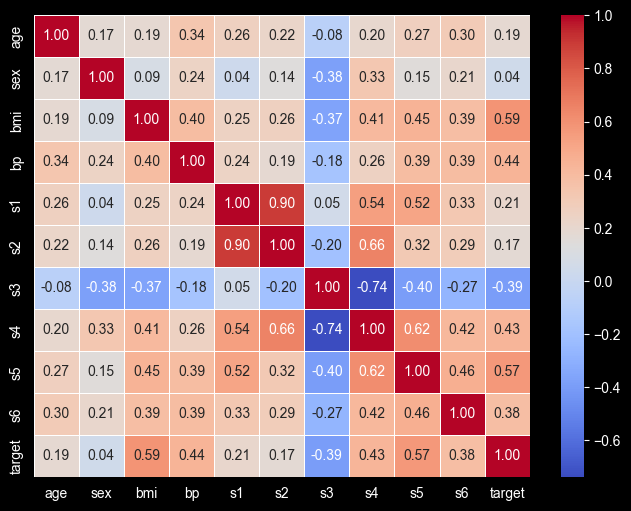

In [6]:
corr_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
linewidths=0.5)

add a title

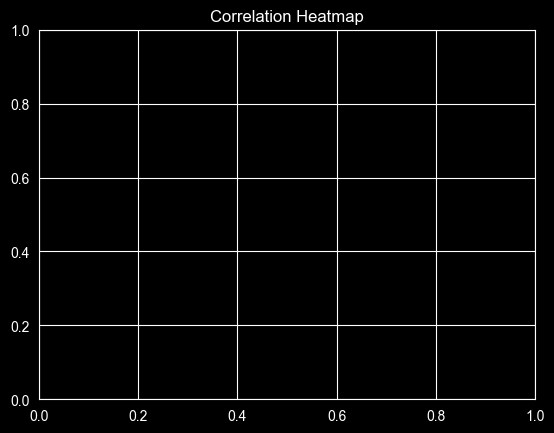

In [7]:
plt.title('Correlation Heatmap')
plt.show()

split the data into training and testing sets

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)

fit the model

In [9]:
model=RFR(n_estimators=100, random_state=42)
model = model.fit(x_train, y_train)

Show the features importances calculated by the random forest technique by default

In [10]:
for col, val in zip(columns,model.feature_importances_):
    print("{}: {:.2f}, ".format(col, val), end="")

age: 0.07, sex: 0.01, bmi: 0.39, bp: 0.11, s1: 0.05, s2: 0.06, s3: 0.05, s4: 0.02, s5: 0.18, s6: 0.06, 

make predictions

In [11]:
predictions=model.predict(x_test)
for val in predictions[0:10]:
    print("{:.0f}\t".format(val), end="")
print()
for val in y_test[0:10]:
    print("{:.0f}\t".format(val), end="")

143	184	156	248	118	116	237	202	146	162	
219	70	202	230	111	84	242	272	94	96	

view RMSE values and R-Squared values

In [12]:
rms=np.sqrt(mse(y_test,predictions))
print("RMSE: {:.2f}".format(rms))
r2=model.score(x_test, y_test)
print("R2: {:.2f}".format(r2))

RMSE: 54.69
R2: 0.49


Apply Permutation Feature Importance

In [13]:
result = permutation_importance(model, x_test, y_test, n_repeats=10,
random_state=42, scoring='neg_root_mean_squared_error')
for i in range(len(result.importances_mean)):
    print(f"Feature {data.feature_names[i]}:{result.importances_mean[i]:.3f} +/- {result.importances_std[i]:.3f}")
dfSummary=pd.DataFrame({'Variable':columns, 'importance':result.importances_mean, 'coeff_lb': result.importances_std[i], 'coeff_ub':result.importances_std[i]})
dfSummary.head(10)

Feature age:0.360 +/- 0.513
Feature sex:0.325 +/- 0.320
Feature bmi:13.754 +/- 1.237
Feature bp:2.453 +/- 0.721
Feature s1:-0.366 +/- 0.277
Feature s2:-0.025 +/- 0.374
Feature s3:1.260 +/- 0.535
Feature s4:0.202 +/- 0.051
Feature s5:9.969 +/- 0.647
Feature s6:1.404 +/- 0.438


,Variable,importance,coeff_lb,coeff_ub
0,age,0.360015,0.438369,0.438369
1,sex,0.325104,0.438369,0.438369
2,bmi,13.753906,0.438369,0.438369
3,bp,2.453359,0.438369,0.438369
4,s1,-0.365711,0.438369,0.438369
5,s2,-0.024554,0.438369,0.438369
6,s3,1.260328,0.438369,0.438369
7,s4,0.202412,0.438369,0.438369
8,s5,9.969055,0.438369,0.438369
9,s6,1.403700,0.438369,0.438369


sort the values

In [14]:
dfSorted=dfSummary.sort_values(by="importance", ascending=True)
dfSorted.head(11)

,Variable,importance,coeff_lb,coeff_ub
4,s1,-0.365711,0.438369,0.438369
5,s2,-0.024554,0.438369,0.438369
7,s4,0.202412,0.438369,0.438369
1,sex,0.325104,0.438369,0.438369
0,age,0.360015,0.438369,0.438369
6,s3,1.260328,0.438369,0.438369
9,s6,1.403700,0.438369,0.438369
3,bp,2.453359,0.438369,0.438369
8,s5,9.969055,0.438369,0.438369
2,bmi,13.753906,0.438369,0.438369


plot the chat bar

Text(0, 0.5, 'variable')

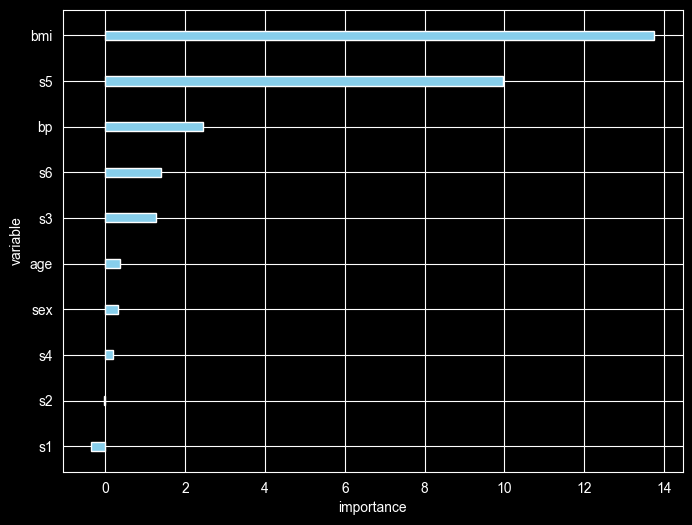

In [15]:
plt.figure(figsize=(8,6))
plt.barh(dfSorted['Variable'], dfSorted['importance'], color='skyblue', height=0.2)
plt.xlabel('importance')
plt.ylabel('variable')